In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("Crop_recommendation.csv")

print("✅ Dataset loaded")
print(f"   Rows     : {df.shape[0]}")
print(f"   Columns  : {df.shape[1]}")
print(f"   Crops    : {df['label'].nunique()} unique classes")
df.head()


✅ Dataset loaded
   Rows     : 2200
   Columns  : 8
   Crops    : 22 unique classes


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


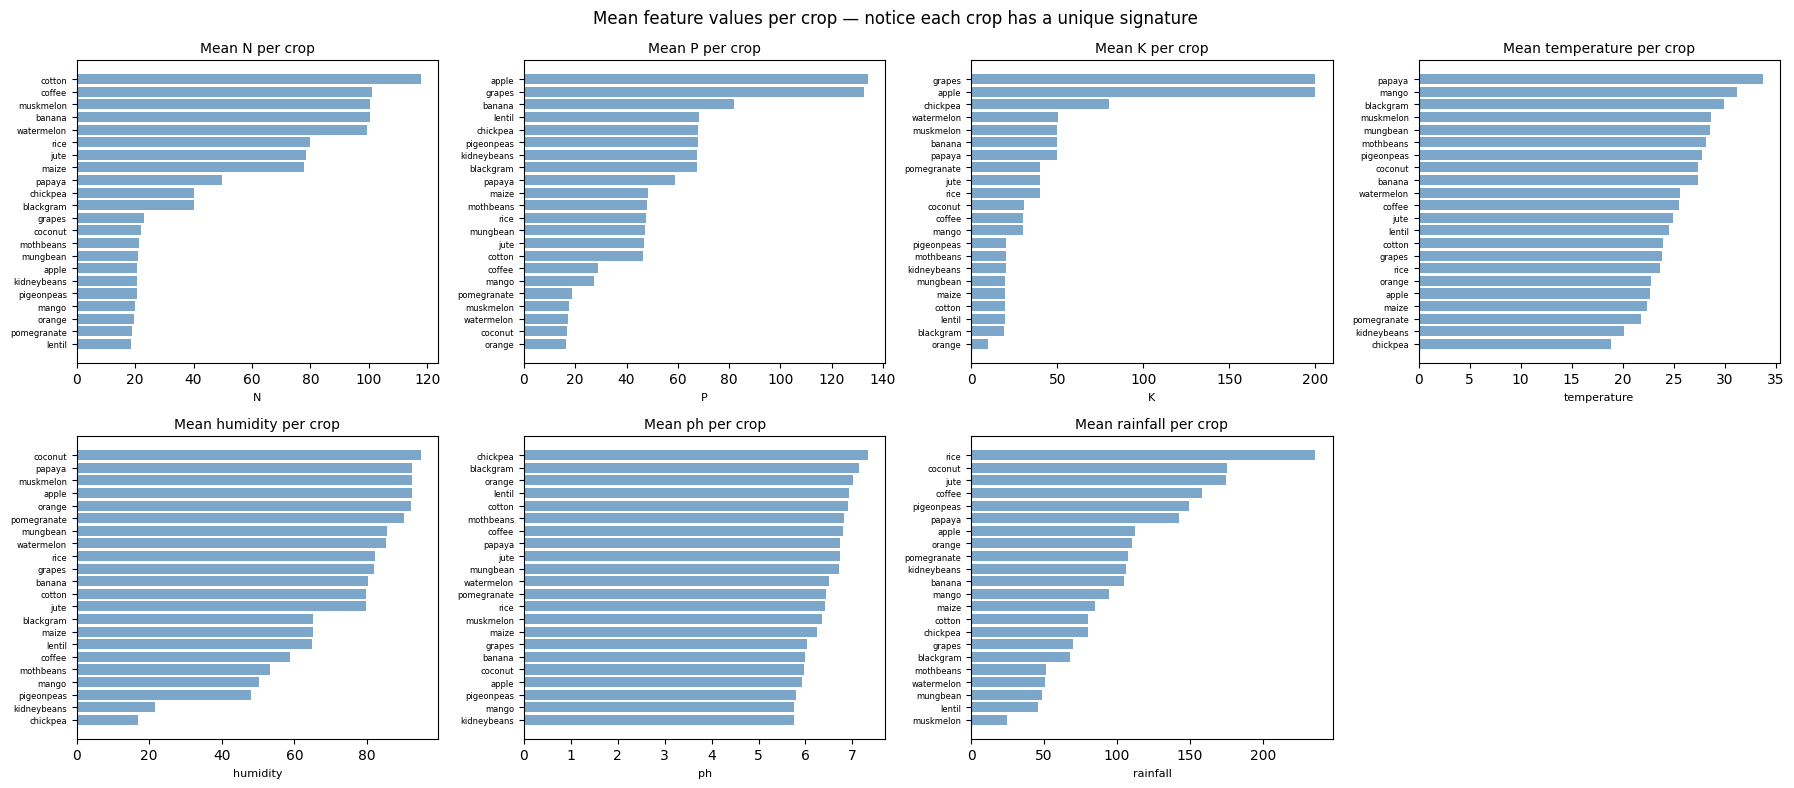

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    crop_means = df.groupby('label')[feat].mean().sort_values()
    ax.barh(crop_means.index, crop_means.values, color='steelblue', alpha=0.7)
    ax.set_title(f'Mean {feat} per crop', fontsize=10)
    ax.set_xlabel(feat, fontsize=8)
    ax.tick_params(axis='y', labelsize=6)

axes[1][3].axis('off')   # hide last empty subplot
plt.suptitle('Mean feature values per crop — notice each crop has a unique signature', fontsize=12)
plt.tight_layout()
plt.show()


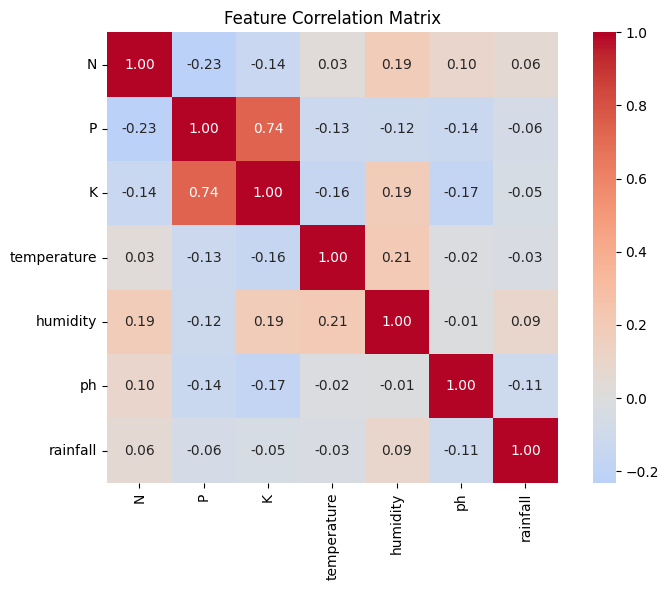

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [4]:
X = df.drop('label', axis=1)   
y = df['label']                

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       
)

print("✅ Split done")
print(f"   X_train : {X_train.shape}  →  {X_train.shape[0]} rows for training")
print(f"   X_test  : {X_test.shape}   →  {X_test.shape[0]} rows for testing")
print(f"\nTraining crops per class (should be 80 each):")
print(y_train.value_counts().to_string())


✅ Split done
   X_train : (1760, 7)  →  1760 rows for training
   X_test  : (440, 7)   →  440 rows for testing

Training crops per class (should be 80 each):
label
orange         80
grapes         80
kidneybeans    80
mothbeans      80
cotton         80
banana         80
lentil         80
mungbean       80
coffee         80
muskmelon      80
apple          80
blackgram      80
pigeonpeas     80
maize          80
rice           80
watermelon     80
jute           80
mango          80
pomegranate    80
papaya         80
coconut        80
chickpea       80


In [5]:

rf = RandomForestClassifier(
    n_estimators=300,     # trees grow until leaves are pure
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"Random Forest accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")

Random Forest accuracy : 0.9932  (99.32%)


In [6]:
rf.predict([[7, 80, 40, 30.3,40, 6.5, 150]])

array(['pigeonpeas'], dtype=object)

In [7]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1607,0,18,14,29.771494,92.007200,7.207991,114.416179
1212,9,122,201,29.587484,80.919344,5.570291,68.064173
362,11,71,24,21.140114,22.718235,5.606620,141.605672
566,38,38,18,26.310518,61.187491,6.294130,35.734038
1671,18,12,8,12.590940,91.816688,6.206053,119.391672
...,...,...,...,...,...,...,...
808,13,64,20,19.134577,62.575269,6.590571,36.469470
422,16,55,19,19.543141,47.191883,6.413544,192.437219
2052,82,48,36,25.793520,81.769040,6.352077,193.241838
2083,90,50,44,26.916437,73.486560,6.253409,171.471638


In [8]:
# ── Cross-validation for reliable estimate ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"5-Fold CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Individual folds   : {[round(s, 4) for s in cv_scores]}")


5-Fold CV Accuracy : 0.9950 ± 0.0027
Individual folds   : [np.float64(0.9955), np.float64(0.9932), np.float64(0.9977), np.float64(0.9977), np.float64(0.9909)]


In [9]:
print("=" * 55)
print(f"  FINAL TEST ACCURACY : {rf_acc:.4f}  ({rf_acc*100:.2f}%)")
print("=" * 55)
print()
print(classification_report(y_test, rf_pred, zero_division=0))


  FINAL TEST ACCURACY : 0.9932  (99.32%)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

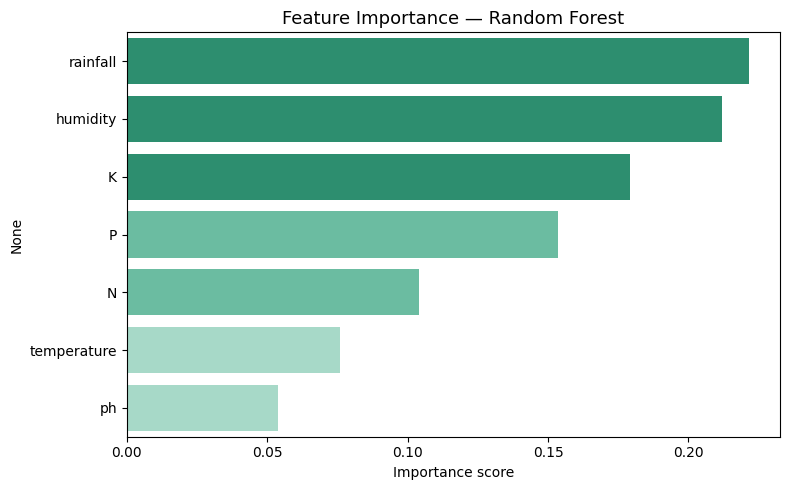

In [10]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#1D9E75' if i < 3 else '#5DCAA5' if i < 5 else '#9FE1CB' for i in range(len(fi))]
sns.barplot(x=fi.values, y=fi.index, palette=colors)
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()




In [11]:

new_farm = pd.DataFrame([{
    'N':           90,    
    'P':           42,    
    'K':           43,    
    'temperature': 21.0,  
    'humidity':    82.0,  
    'ph':          6.5,   
    'rainfall':    210.0  
}])

prediction = rf.predict(new_farm)[0]

proba = pd.Series(rf.predict_proba(new_farm)[0], index=rf.classes_)
top5  = proba.sort_values(ascending=False).head(5)

print(f"🌾 Recommended crop : {prediction.upper()}")
print()
print("Top 5 predictions with confidence:")
for crop, prob in top5.items():
    bar = '█' * int(prob * 40)
    print(f"  {crop:<15} {prob*100:5.1f}%  {bar}")


🌾 Recommended crop : RICE

Top 5 predictions with confidence:
  rice             96.7%  ██████████████████████████████████████
  jute              3.3%  █
  blackgram         0.0%  
  chickpea          0.0%  
  apple             0.0%  


In [12]:
pd.Series(rf.predict_proba(new_farm)[0], index=rf.classes_)


apple          0.000000
banana         0.000000
blackgram      0.000000
chickpea       0.000000
coconut        0.000000
coffee         0.000000
cotton         0.000000
grapes         0.000000
jute           0.033333
kidneybeans    0.000000
lentil         0.000000
maize          0.000000
mango          0.000000
mothbeans      0.000000
mungbean       0.000000
muskmelon      0.000000
orange         0.000000
papaya         0.000000
pigeonpeas     0.000000
pomegranate    0.000000
rice           0.966667
watermelon     0.000000
dtype: float64

In [26]:
from sklearn.model_selection import GridSearchCV

# Number of trees in random forest
n_estimators = [600,700,800,900,1000]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

rf2 = RandomForestClassifier()
rf_grid = GridSearchCV(estimator = rf2, 
                       param_grid = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

{'n_estimators': [600, 700, 800, 900, 1000], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0]}


In [27]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [2, 8, ...], 'max_features': [0.2, 0.6, ...], 'max_samples': [0.5, 0.75, ...], 'n_estimators': [600, 700, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,600


In [22]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 1.0,
 'n_estimators': 600}

In [23]:
rf_grid.best_score_

np.float64(0.9943181818181819)

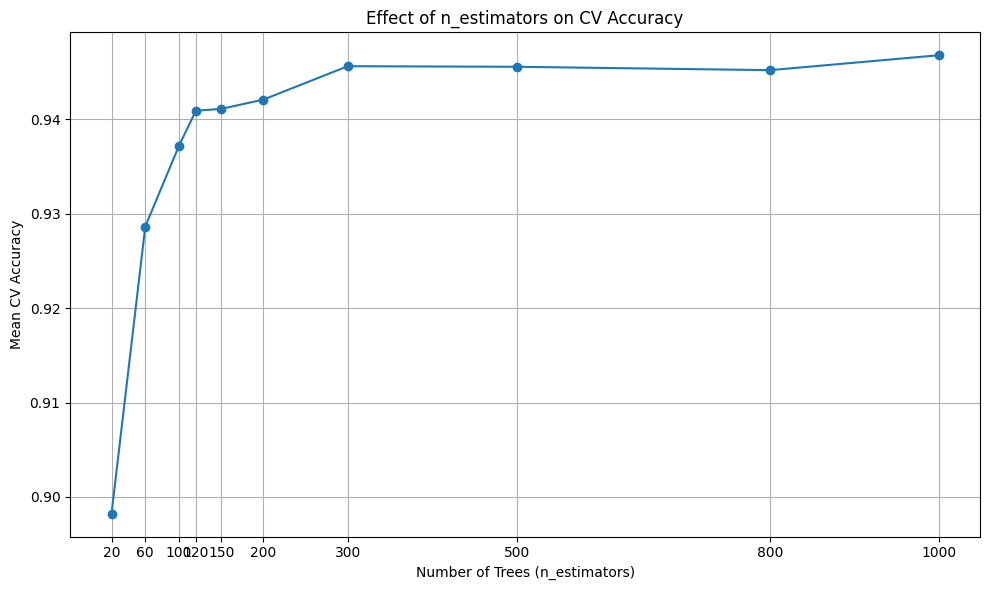

In [19]:
#graph for n_estimators
results = pd.DataFrame(rf_grid.cv_results_)

n_estimators_values = results['param_n_estimators'].unique()
mean_test_scores = results.groupby('param_n_estimators')['mean_test_score'].mean()
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_values, mean_test_scores, marker='o')
plt.title('Effect of n_estimators on CV Accuracy')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(n_estimators_values)
plt.grid()
plt.tight_layout()
plt.show()


In [14]:
import joblib
import json

MODEL_PATH = 'crop_model.joblib'
META_PATH  = 'model_meta.json'

joblib.dump(rf, MODEL_PATH)

meta = {
    'model':    'RandomForestClassifier',
    'features': X.columns.tolist(),
    'classes':  rf.classes_.tolist(),
    'n_estimators': rf.n_estimators,
    'accuracy': round(rf_acc, 4),
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

print(f"✅ Model saved  → {MODEL_PATH}  ({__import__('os').path.getsize(MODEL_PATH)/1024:.1f} KB)")
print(f"✅ Metadata saved → {META_PATH}")
print()
print("Metadata contents:")
print(json.dumps(meta, indent=2))


✅ Model saved  → crop_model.joblib  (10771.6 KB)
✅ Metadata saved → model_meta.json

Metadata contents:
{
  "model": "RandomForestClassifier",
  "features": [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
  ],
  "classes": [
    "apple",
    "banana",
    "blackgram",
    "chickpea",
    "coconut",
    "coffee",
    "cotton",
    "grapes",
    "jute",
    "kidneybeans",
    "lentil",
    "maize",
    "mango",
    "mothbeans",
    "mungbean",
    "muskmelon",
    "orange",
    "papaya",
    "pigeonpeas",
    "pomegranate",
    "rice",
    "watermelon"
  ],
  "n_estimators": 300,
  "accuracy": 0.9932
}


In [15]:

loaded_model = joblib.load(MODEL_PATH)

test_input = [[90, 42, 43, 21.0, 82.0, 6.5, 210.0]]
prediction = loaded_model.predict(test_input)[0]
confidence = loaded_model.predict_proba(test_input).max()

print(f"✅ Loaded model predicts: {prediction.upper()}  (confidence: {confidence*100:.1f}%)")
print("   Model reload successful — ready for API deployment.")


✅ Loaded model predicts: RICE  (confidence: 96.7%)
   Model reload successful — ready for API deployment.
